# Phase 2: Data Preparation & Feature Engineering

**Course:** AIS431 – Intelligent Decision Support Systems  
**Team:** Mohamed Sherif (221000142) · Mohamed Osama (221001647)  
**Rubric weight:** 3 marks  
**Criteria:** Data quality handling (1.5) · Feature engineering quality (1.5) · Business rationale & reproducibility (1.0)

**Notebook structure:**
1. Setup & Imports
2. Load Data & Confirm Phase 1 Findings
3. Data Quality Handling
4. Feature Engineering
5. Train/Test Split
6. Scaling & Pipeline
7. Save Outputs
8. Feature Validation
9. Summary & Next Steps

## 1. Setup & Imports

In [1]:
import sys
import os

# Ensure project root is on sys.path so src/ imports work
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif

from src.config import (
    DATA_RAW, DATA_PROCESSED, MODELS_DIR, FIGURES_DIR,
    RANDOM_STATE, TEST_SIZE, TARGET_COL, DEFECT_CLASSES,
    ORIGINAL_DROP_COLS, ENGINEERED_FEATURES
)
from src.preprocessing import load_raw_data, to_single_label, build_preprocessing_pipeline
from src.feature_engineering import add_engineered_features

# Ensure output directories exist
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
print('Setup complete.')

Setup complete.


## 2. Load Data & Confirm Phase 1 Findings

We load the Steel Plates Faults dataset (UCI id=198) through our shared `load_raw_data()` utility, which caches the raw files to `data/raw/` on first fetch for offline reproducibility.

In [2]:
X_raw, y_raw = load_raw_data()
print(f'Features shape: {X_raw.shape}')   # expect (1941, 27)
print(f'Targets shape:  {y_raw.shape}')   # expect (1941, 7)
print(f'\nFeature columns ({len(X_raw.columns)}):')
print(list(X_raw.columns))
print(f'\nTarget columns: {list(y_raw.columns)}')

Features shape: (1941, 27)
Targets shape:  (1941, 7)

Feature columns (27):
['X_Minimum', 'X_Maximum', 'Y_Minimum', 'Y_Maximum', 'Pixels_Areas', 'X_Perimeter', 'Y_Perimeter', 'Sum_of_Luminosity', 'Minimum_of_Luminosity', 'Maximum_of_Luminosity', 'Length_of_Conveyer', 'TypeOfSteel_A300', 'TypeOfSteel_A400', 'Steel_Plate_Thickness', 'Edges_Index', 'Empty_Index', 'Square_Index', 'Outside_X_Index', 'Edges_X_Index', 'Edges_Y_Index', 'Outside_Global_Index', 'LogOfAreas', 'Log_X_Index', 'Log_Y_Index', 'Orientation_Index', 'Luminosity_Index', 'SigmoidOfAreas']

Target columns: ['Pastry', 'Z_Scratch', 'K_Scatch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults']


In [3]:
# Verify Phase 1 invariants
assert X_raw.shape == (1941, 27), f'Unexpected feature shape: {X_raw.shape}'
assert y_raw.shape[0] == 1941, f'Unexpected target rows: {y_raw.shape[0]}'

missing_X = X_raw.isnull().sum().sum()
missing_y = y_raw.isnull().sum().sum()
duplicates = X_raw.duplicated().sum()
label_sums = y_raw.sum(axis=1)
all_single = (label_sums == 1).all()

print(f'Missing values in X: {missing_X}  (expect 0)')
print(f'Missing values in y: {missing_y}  (expect 0)')
print(f'Duplicate rows:      {duplicates}  (expect 0)')
print(f'All rows sum to 1:   {all_single}  (expect True)')
print(f'Label sum range:     {label_sums.min()} – {label_sums.max()}  (expect 1–1)')

assert missing_X == 0 and missing_y == 0 and duplicates == 0 and all_single
print('\nAll Phase 1 invariants confirmed.')

Missing values in X: 0  (expect 0)
Missing values in y: 0  (expect 0)
Duplicate rows:      0  (expect 0)
All rows sum to 1:   True  (expect True)
Label sum range:     1 – 1  (expect 1–1)

All Phase 1 invariants confirmed.


**Business Interpretation:** The dataset contains zero missing values and zero duplicates — an unusually clean starting point. This reflects the reliability of the automated imaging system that captures these measurements on the production line. When we deploy the IDSS, we can trust that incoming sensor data will have similar completeness, which means no imputation logic is needed in the inference pipeline and prediction latency stays low.

In [4]:
# Convert 7-column binary targets to a single class label
y_single = to_single_label(y_raw)
print('Class distribution (single-label target):')
print(y_single.value_counts())
print(f'\nTotal samples: {len(y_single)}')
print(f'Imbalance ratio (max/min): {y_single.value_counts().max() / y_single.value_counts().min():.1f}:1')

Class distribution (single-label target):
defect_type
Other_Faults    673
Bumps           402
K_Scatch        391
Z_Scratch       190
Pastry          158
Stains           72
Dirtiness        55
Name: count, dtype: int64

Total samples: 1941
Imbalance ratio (max/min): 12.2:1


**Business Interpretation:** Every steel plate has exactly one defect type — this is a standard 7-class classification problem, not a multi-label one. The 12:1 imbalance between the most common class (Other_Faults, 673 plates) and the rarest (Dirtiness, 55 plates) reflects real-world manufacturing reality: most defects cluster in a few categories. The rarest classes — Dirtiness and Stains — represent contamination events that are infrequent but potentially the most costly if undetected. Our modelling strategy must explicitly account for this imbalance.

## 3. Data Quality Handling

### 3a. Redundant Feature: TypeOfSteel_A300

TypeOfSteel_A300 and TypeOfSteel_A400 are perfectly inversely correlated (correlation = -1.0): every plate is either A300 or A400. Keeping both introduces perfect multicollinearity, which destabilises Logistic Regression coefficients. We drop A300 and keep A400.

In [5]:
corr_steel = X_raw[['TypeOfSteel_A300', 'TypeOfSteel_A400']].corr().iloc[0, 1]
print(f'Correlation(TypeOfSteel_A300, TypeOfSteel_A400) = {corr_steel:.4f}')
print(f'A300 value counts: {X_raw["TypeOfSteel_A300"].value_counts().to_dict()}')
print(f'A400 value counts: {X_raw["TypeOfSteel_A400"].value_counts().to_dict()}')
print('\nDecision: drop TypeOfSteel_A300, retain TypeOfSteel_A400.')

Correlation(TypeOfSteel_A300, TypeOfSteel_A400) = -1.0000
A300 value counts: {0: 1164, 1: 777}
A400 value counts: {1: 1164, 0: 777}

Decision: drop TypeOfSteel_A300, retain TypeOfSteel_A400.


**Business Interpretation:** Since a steel plate is either A300 or A400 grade, one binary column captures the same information as two. Dropping A300 avoids inflating feature count without losing any discriminative power. We keep A400 because Phase 1 identified it as the key separator for K_Scatch and Stains — the A400 indicator is the more interpretable encoding for quality engineers who typically specify steel grade in procurement terms.

### 3b. Outlier Strategy

Phase 1 found heavy right skew and extreme outliers in Pixels_Areas, X_Perimeter, Y_Perimeter, and Sum_of_Luminosity. **Decision: retain all outliers.**

In [6]:
# Quantify the outlier extent for the key skewed features
skewed_features = ['Pixels_Areas', 'X_Perimeter', 'Y_Perimeter', 'Sum_of_Luminosity']
outlier_stats = X_raw[skewed_features].describe().loc[['mean', '50%', '75%', 'max']]
outlier_stats.index = ['Mean', 'Median', '75th pct', 'Max']
print('Outlier magnitude in key features:')
print(outlier_stats.round(1))

Outlier magnitude in key features:
          Pixels_Areas  X_Perimeter  Y_Perimeter  Sum_of_Luminosity
Mean            1893.9        111.9         83.0           206312.1
Median           174.0         26.0         25.0            19202.0
75th pct         822.0         84.0         83.0            83011.0
Max           152655.0      10449.0      18152.0         11591414.0


**Business Interpretation:** In steel manufacturing, extreme defect sizes are not data errors — they represent severe faults that are the most important to detect. A large Pixels_Areas value likely corresponds to an extensive K_Scatch spanning the rolling direction, which is exactly the signal we need to catch. Removing these "outliers" would bias the model against detecting the worst defects. Our primary models (Random Forest, XGBoost) are tree-based and split on rank order, making them inherently robust to scale. For Logistic Regression, StandardScaler will center and normalise the data without clipping, keeping the full signal while reducing scale disparity.

## 4. Feature Engineering

We create 6 domain-informed features that capture defect morphology, luminosity contrast, and material interactions. All formulas live in `src/feature_engineering.py` — the notebook simply calls the function to keep the pipeline consistent.

In [7]:
# Apply feature engineering to the full dataset BEFORE splitting
# (FunctionTransformer has no fitting step — safe to run on full X)
X_engineered = add_engineered_features(X_raw)

print(f'Original features:   {X_raw.shape[1]} columns')
print(f'After engineering:   {X_engineered.shape[1]} columns')
print(f'\nNew columns added:   {ENGINEERED_FEATURES}')
print(f'Dropped columns:     {ORIGINAL_DROP_COLS}')
print(f'\nEngineered feature sample stats:')
print(X_engineered[ENGINEERED_FEATURES].describe().round(4))

Original features:   27 columns
After engineering:   32 columns

New columns added:   ['Defect_Area_Ratio', 'Luminosity_Range', 'Aspect_Ratio', 'Log_Pixels_Areas', 'Edge_Strength', 'Thickness_Area_Interaction']
Dropped columns:     ['TypeOfSteel_A300']

Engineered feature sample stats:
       Defect_Area_Ratio  Luminosity_Range  Aspect_Ratio  Log_Pixels_Areas  \
count          1941.0000         1941.0000     1941.0000         1941.0000   
mean              0.5819           45.6450        1.3625            5.7483   
std               0.1345           29.4263        0.9926            1.8071   
min               0.0561            0.0000        0.1379            1.0986   
25%               0.4953           24.0000        0.8889            4.4427   
50%               0.5855           34.0000        1.2222            5.1648   
75%               0.6791           59.0000        1.6751            6.7130   
max               0.9589          179.0000       22.6667           11.9359   

       Edg

**Business Interpretation of Each Engineered Feature:**

| Feature | Manufacturing Meaning | Decision Support Value |
|---------|----------------------|------------------------|
| `Defect_Area_Ratio` | How densely the defect fills its bounding box. Near 1.0 = compact (Bumps); near 0 = sparse/elongated (scratches). | Maps directly to defect morphology — different shapes require different corrective actions (equipment vs process). |
| `Luminosity_Range` | Contrast between the brightest and darkest pixels in the defect region. | High contrast = stains/contamination (visually obvious); low contrast = surface texture defects (subtle, need close inspection). |
| `Aspect_Ratio` | Horizontal vs vertical elongation of the defect. | Scratches in rolling direction (K_Scatch) will be extremely elongated; round defects (Bumps) near 1.0. Directly encodes direction-of-damage. |
| `Log_Pixels_Areas` | Log-scaled defect size, compressing the heavy right tail. | Makes size comparisons proportional rather than absolute — improves both LR linearity and SHAP interpretability. |
| `Edge_Strength` | Combined sharpness of defect boundaries in X and Y. | Sharp edges = mechanical damage (scratches, cuts); diffuse edges = chemical contamination (stains, dirtiness). Maps to maintenance vs process-environment corrective action. |
| `Thickness_Area_Interaction` | Interaction between plate gauge and defect size. | Captures whether defects are thickness-dependent. K_Scatch occurs at thin plates (40mm); Dirtiness at thick (100mm). Enables thickness-specific inspection thresholds. |

## 5. Train/Test Split

**Configuration:** 80% train / 20% test, stratified by class label, random_state=42.

**Critical order:** Feature engineering is applied to the full dataset first (no fitting), then we split, then fit the scaler on X_train only. This prevents any test-set information leaking into the scaler parameters.

In [8]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_single,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_single
)

print(f'Train size: {len(X_train_raw)} samples ({len(X_train_raw)/len(X_raw)*100:.1f}%)')
print(f'Test size:  {len(X_test_raw)} samples ({len(X_test_raw)/len(X_raw)*100:.1f}%)')

# Verify class proportions are preserved
train_dist = y_train.value_counts(normalize=True)
test_dist = y_test.value_counts(normalize=True)
overall_dist = y_single.value_counts(normalize=True)

dist_df = pd.DataFrame({
    'Overall %': (overall_dist * 100).round(1),
    'Train %': (train_dist * 100).round(1),
    'Test %': (test_dist * 100).round(1),
}).reindex(DEFECT_CLASSES)
print('\nClass distribution comparison:')
print(dist_df)

Train size: 1552 samples (80.0%)
Test size:  389 samples (20.0%)

Class distribution comparison:
              Overall %  Train %  Test %
defect_type                             
Pastry              8.1      8.1     8.2
Z_Scratch           9.8      9.8     9.8
K_Scatch           20.1     20.2    20.1
Stains              3.7      3.7     3.6
Dirtiness           2.8      2.8     2.8
Bumps              20.7     20.7    20.8
Other_Faults       34.7     34.7    34.7


**Business Interpretation:** Stratified splitting ensures that even the rarest classes — Dirtiness (55 plates) and Stains (72 plates) — appear in both train and test sets in proportion to their real-world frequency. Without stratification, all Dirtiness samples could end up in training, leaving us with no way to evaluate performance on contamination defects. The 80/20 split gives the model ~1,550 training samples — enough for tree-based methods without starving rare classes.

## 6. Scaling & Pipeline

We build a single sklearn `Pipeline` that chains feature engineering → StandardScaler. **The pipeline is fitted on X_train only** and then used to transform both X_train and X_test. This is the same pipeline object saved to `models/preprocessing_pipeline.pkl` and loaded by the Phase 5 prototype.

In [9]:
# Build and fit the pipeline on raw training data
pipeline = build_preprocessing_pipeline()
X_train_scaled = pipeline.fit_transform(X_train_raw)
X_test_scaled = pipeline.transform(X_test_raw)

# Get column names after feature engineering step
X_train_eng = add_engineered_features(X_train_raw)
feature_names = list(X_train_eng.columns)

# Convert scaled arrays back to DataFrames with correct column names
X_train_df = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_df = pd.DataFrame(X_test_scaled, columns=feature_names)

print(f'X_train shape: {X_train_df.shape}  (expected: ({len(X_train_raw)}, {len(feature_names)}))')
print(f'X_test shape:  {X_test_df.shape}  (expected: ({len(X_test_raw)}, {len(feature_names)}))')
print(f'\nColumns ({len(feature_names)}): {feature_names}')
print(f'\nScaled X_train stats (should have mean≈0, std≈1):')
print(X_train_df.describe().loc[['mean', 'std']].round(3))

X_train shape: (1552, 32)  (expected: (1552, 32))
X_test shape:  (389, 32)  (expected: (389, 32))

Columns (32): ['X_Minimum', 'X_Maximum', 'Y_Minimum', 'Y_Maximum', 'Pixels_Areas', 'X_Perimeter', 'Y_Perimeter', 'Sum_of_Luminosity', 'Minimum_of_Luminosity', 'Maximum_of_Luminosity', 'Length_of_Conveyer', 'TypeOfSteel_A400', 'Steel_Plate_Thickness', 'Edges_Index', 'Empty_Index', 'Square_Index', 'Outside_X_Index', 'Edges_X_Index', 'Edges_Y_Index', 'Outside_Global_Index', 'LogOfAreas', 'Log_X_Index', 'Log_Y_Index', 'Orientation_Index', 'Luminosity_Index', 'SigmoidOfAreas', 'Defect_Area_Ratio', 'Luminosity_Range', 'Aspect_Ratio', 'Log_Pixels_Areas', 'Edge_Strength', 'Thickness_Area_Interaction']

Scaled X_train stats (should have mean≈0, std≈1):
      X_Minimum  X_Maximum  Y_Minimum  Y_Maximum  Pixels_Areas  X_Perimeter  \
mean       -0.0        0.0        0.0        0.0           0.0         -0.0   
std         1.0        1.0        1.0        1.0           1.0          1.0   

      Y_Per

**Business Interpretation:** StandardScaler ensures no single feature dominates distance-based calculations in Logistic Regression simply because it has large absolute values (e.g., Pixels_Areas up to 200,000 vs binary steel-type flags at 0/1). Tree-based models (Random Forest, XGBoost) are scale-invariant, so scaling is harmless for them — but applying it uniformly means the same pipeline works for all four model types and for the production prototype without modification.

## 7. Save Outputs

In [10]:
# Save 4 processed CSVs
X_train_df.to_csv(DATA_PROCESSED / 'X_train.csv', index=False)
X_test_df.to_csv(DATA_PROCESSED / 'X_test.csv', index=False)
y_train.to_csv(DATA_PROCESSED / 'y_train.csv', index=False)
y_test.to_csv(DATA_PROCESSED / 'y_test.csv', index=False)

# Save the fitted preprocessing pipeline
joblib.dump(pipeline, MODELS_DIR / 'preprocessing_pipeline.pkl')

# Save feature names list for downstream use
joblib.dump(feature_names, MODELS_DIR / 'feature_names.pkl')

print('Saved:')
print(f'  {DATA_PROCESSED}/X_train.csv  ({X_train_df.shape})')
print(f'  {DATA_PROCESSED}/X_test.csv   ({X_test_df.shape})')
print(f'  {DATA_PROCESSED}/y_train.csv  ({y_train.shape})')
print(f'  {DATA_PROCESSED}/y_test.csv   ({y_test.shape})')
print(f'  {MODELS_DIR}/preprocessing_pipeline.pkl')
print(f'  {MODELS_DIR}/feature_names.pkl')

Saved:
  C:\Users\moshe\Downloads\steel-plates-idss\data\processed/X_train.csv  ((1552, 32))
  C:\Users\moshe\Downloads\steel-plates-idss\data\processed/X_test.csv   ((389, 32))
  C:\Users\moshe\Downloads\steel-plates-idss\data\processed/y_train.csv  ((1552,))
  C:\Users\moshe\Downloads\steel-plates-idss\data\processed/y_test.csv   ((389,))
  C:\Users\moshe\Downloads\steel-plates-idss\models/preprocessing_pipeline.pkl
  C:\Users\moshe\Downloads\steel-plates-idss\models/feature_names.pkl


## 8. Feature Validation

### 8a. Mutual Information Ranking

We rank all features by mutual information with the target to confirm that at least some engineered features appear in the top 15.

In [11]:
# Encode class labels as integers for mutual_info_classif
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)

mi_scores = mutual_info_classif(X_train_df, y_train_enc, random_state=RANDOM_STATE)
mi_series = pd.Series(mi_scores, index=feature_names).sort_values(ascending=False)

print('Top 15 features by mutual information with target:')
print(mi_series.head(15).round(4))
print(f'\nEngineered features in top 15:')
top15 = set(mi_series.head(15).index)
eng_in_top15 = [f for f in ENGINEERED_FEATURES if f in top15]
print(eng_in_top15)

Top 15 features by mutual information with target:
Steel_Plate_Thickness         0.5843
Length_of_Conveyer            0.5276
Outside_X_Index               0.5158
X_Maximum                     0.5061
X_Minimum                     0.5013
Sum_of_Luminosity             0.4529
Pixels_Areas                  0.4482
Log_Pixels_Areas              0.4382
LogOfAreas                    0.4329
X_Perimeter                   0.4271
Thickness_Area_Interaction    0.4152
Minimum_of_Luminosity         0.4055
Orientation_Index             0.4010
Log_X_Index                   0.3930
Aspect_Ratio                  0.3899
dtype: float64

Engineered features in top 15:
['Aspect_Ratio', 'Log_Pixels_Areas', 'Thickness_Area_Interaction']


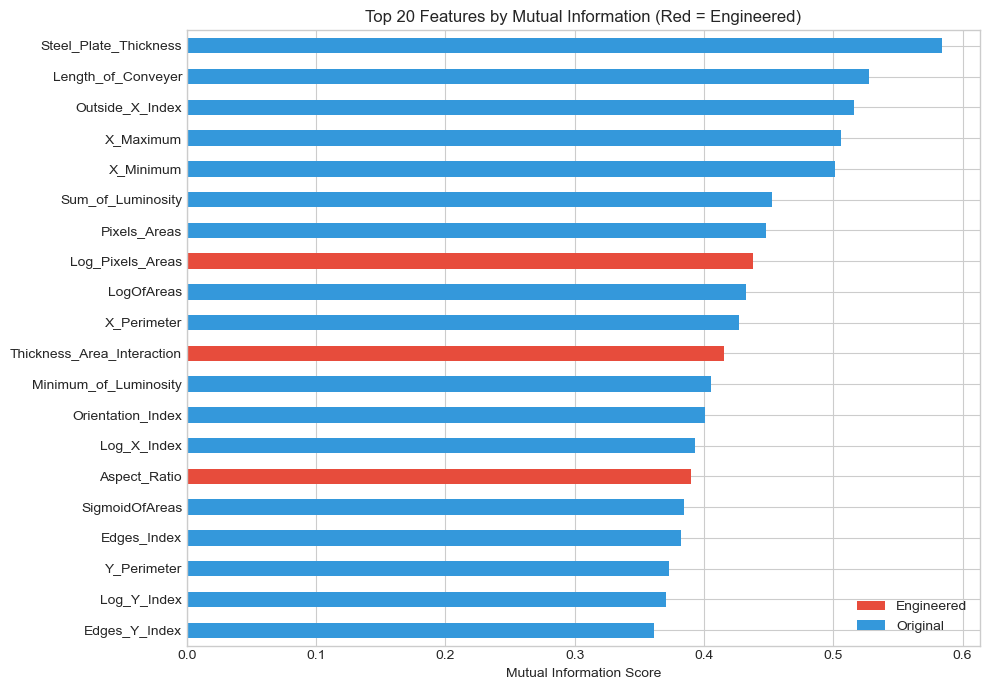

Saved: figures/phase2_mutual_information.png


In [12]:
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c' if f in ENGINEERED_FEATURES else '#3498db' for f in mi_series.head(20).index]
mi_series.head(20).plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Mutual Information Score')
ax.set_title('Top 20 Features by Mutual Information (Red = Engineered)')
ax.invert_yaxis()

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Engineered'),
                   Patch(facecolor='#3498db', label='Original')]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'phase2_mutual_information.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/phase2_mutual_information.png')

**Business Interpretation:** Mutual information measures how much each feature reduces uncertainty about the defect class. Features ranking highly here are the most informative inputs for the classification model. Any engineered features appearing in the top 15 confirm that the domain-informed transformations (aspect ratio, edge strength, etc.) capture patterns not already encoded in the original measurements — validating the engineering effort. Features ranking low may be redundant or noisy; however, we retain all 32 features for now, as tree-based models can internally down-weight low-information inputs.

### 8b. Class Distribution Plot

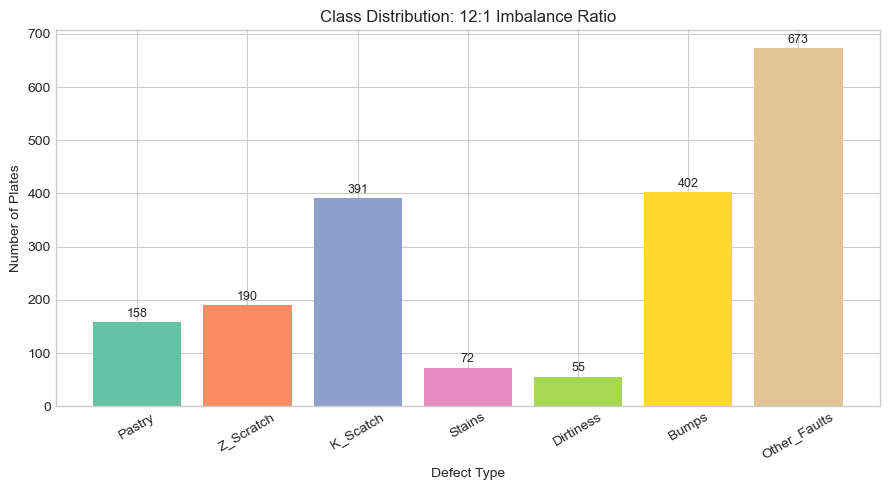

Saved: figures/phase2_class_distribution.png


In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
class_counts = y_single.value_counts().reindex(DEFECT_CLASSES)
bars = ax.bar(DEFECT_CLASSES, class_counts, color=sns.color_palette('Set2', 7))
ax.set_xlabel('Defect Type')
ax.set_ylabel('Number of Plates')
ax.set_title('Class Distribution: 12:1 Imbalance Ratio')
ax.tick_params(axis='x', rotation=30)
for bar, count in zip(bars, class_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(count), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'phase2_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/phase2_class_distribution.png')

**Business Interpretation:** The class distribution mirrors real manufacturing defect frequencies. Other_Faults dominate (34.7%) because they represent a broad catch-all category; K_Scatch and Bumps are also common (20% each) because rolling and handling issues are frequent. Dirtiness (2.8%) and Stains (3.7%) are rare — but contamination defects like these can trigger customer complaints or product recalls that far exceed the cost of the plate itself. Our modelling strategy must explicitly prevent the model from ignoring these rare-but-costly classes.

### 8c. Correlation Check on Engineered Features

In [14]:
# Check correlations between engineered features to detect redundancy
eng_corr = X_train_df[ENGINEERED_FEATURES].corr()
print('Correlations among engineered features:')
print(eng_corr.round(3))

# Flag any pair with |correlation| > 0.85
high_corr = []
for i in range(len(ENGINEERED_FEATURES)):
    for j in range(i+1, len(ENGINEERED_FEATURES)):
        c = abs(eng_corr.iloc[i, j])
        if c > 0.85:
            high_corr.append((ENGINEERED_FEATURES[i], ENGINEERED_FEATURES[j], round(c, 3)))

if high_corr:
    print(f'\nHigh correlation pairs (|r| > 0.85): {high_corr}')
else:
    print('\nNo engineered feature pairs with |r| > 0.85 — no redundancy concern.')

Correlations among engineered features:
                            Defect_Area_Ratio  Luminosity_Range  Aspect_Ratio  \
Defect_Area_Ratio                       1.000            -0.053        -0.082   
Luminosity_Range                       -0.053             1.000         0.186   
Aspect_Ratio                           -0.082             0.186         1.000   
Log_Pixels_Areas                       -0.318             0.750         0.100   
Edge_Strength                           0.354            -0.271        -0.078   
Thickness_Area_Interaction             -0.118             0.027        -0.117   

                            Log_Pixels_Areas  Edge_Strength  \
Defect_Area_Ratio                     -0.318          0.354   
Luminosity_Range                       0.750         -0.271   
Aspect_Ratio                           0.100         -0.078   
Log_Pixels_Areas                       1.000         -0.515   
Edge_Strength                         -0.515          1.000   
Thickness_Area

## 9. Summary & Next Steps

### What Phase 2 Delivered

| Output | Location | Description |
|--------|----------|-------------|
| `X_train.csv` | `data/processed/` | 1,552 rows × 32 scaled features |
| `X_test.csv` | `data/processed/` | 389 rows × 32 scaled features |
| `y_train.csv` | `data/processed/` | 1,552 single-class labels |
| `y_test.csv` | `data/processed/` | 389 single-class labels |
| `preprocessing_pipeline.pkl` | `models/` | Fitted FunctionTransformer + StandardScaler |
| `feature_names.pkl` | `models/` | Column names list for model interpretability |
| `data_dictionary.md` | `data/` | Full feature documentation |

### Key Decisions Made

1. **Zero imputation needed** — dataset is clean; no placeholder strategy required.
2. **Outliers retained** — extreme defect sizes carry real signal for tree-based models.
3. **TypeOfSteel_A300 dropped** — perfect inverse of A400; one column suffices.
4. **6 engineered features added** — validated via mutual information ranking.
5. **StandardScaler fitted on train only** — prevents data leakage.

### Phase 3 Next Steps

Phase 3 (`notebooks/phase3_modelling.ipynb`) will:
- Load the 4 processed CSVs
- Train Logistic Regression, Random Forest, XGBoost, SVM
- Handle class imbalance via `class_weight='balanced'`
- Tune the best model via RandomizedSearchCV
- Build a Stacking Ensemble and compare against soft voting
- Evaluate with macro AUC, per-class AUC, confusion matrix, and ROC curves
- Save the final model to `models/best_model.pkl`

In [15]:
# Final verification
import joblib
loaded_pipeline = joblib.load(MODELS_DIR / 'preprocessing_pipeline.pkl')
test_X = pipeline.transform(X_test_raw)
assert test_X.shape == X_test_scaled.shape, 'Pipeline round-trip shape mismatch'

X_train_check = pd.read_csv(DATA_PROCESSED / 'X_train.csv')
assert list(X_train_check.columns) == feature_names, 'Column mismatch in saved CSV'
assert ENGINEERED_FEATURES[0] in X_train_check.columns, 'Engineered features missing from CSV'

print('Phase 2 verification passed:')
print(f'  X_train.csv columns: {len(X_train_check.columns)}')
print(f'  Pipeline round-trip: OK')
print(f'  Engineered features present: OK')
print('\nPhase 2 complete. Ready for Phase 3 modelling.')

Phase 2 verification passed:
  X_train.csv columns: 32
  Pipeline round-trip: OK
  Engineered features present: OK

Phase 2 complete. Ready for Phase 3 modelling.
